In [1]:
# Подключение класса для создания нейронной сети прямого распространения
from tensorflow.keras.models import Sequential
# Подключение класса для создания полносвязного слоя
from tensorflow.keras.layers import Dense
# Подключение оптимизатора
from tensorflow.keras.optimizers import Adam
# Подключение утилит для to_categorical
from tensorflow.keras import utils
# Подключение библиотеки для загрузки изображений
from tensorflow.keras.preprocessing import image
# Подключение библиотеки для работы с массивами
import numpy as np
# Подключение модуля для работы с файлами
import os
# Подключение библиотек для отрисовки изображений
import matplotlib.pyplot as plt
from PIL import Image
# Вывод изображения в ноутбуке, а не в консоли или файле
%matplotlib inline
from sklearn.model_selection import train_test_split

In [2]:
# Загрузка датасета из облака
import gdown
gdown.download('https://storage.yandexcloud.net/aiueducation/Content/base/l3/hw_pro.zip', None, quiet=True)

'hw_pro.zip'

In [3]:
# Распаковываем архив hw_light.zip в папку hw_light
!unzip -q hw_pro.zip

In [4]:
# Путь к директории с базой
base_dir = '/content/hw_pro'
# Создание пустого списка для загрузки изображений обучающей выборки
x_train = []
# Создание списка для меток классов
y_train = []
# Задание высоты и ширины загружаемых изображений
img_height = 20
img_width = 20
# Перебор папок в директории базы
for patch in os.listdir(base_dir):
    # Перебор файлов в папках
    for img in os.listdir(base_dir + '/' + patch):
        # Добавление в список изображений текущей картинки
        x_train.append(image.img_to_array(image.load_img(base_dir + '/' + patch + '/' + img,
                                                         target_size=(img_height, img_width),
                                                         color_mode='grayscale')))
        # Добавление в массив меток, соответствующих классам
        if patch == '0':
            y_train.append(0)
        else:
            y_train.append(1)
# Преобразование в numpy-массив загруженных изображений и меток классов
x_train = np.array(x_train)
y_train = np.array(y_train)
x_train, x_test, y_train, y_test = train_test_split(
    x_train,
    y_train,
    test_size=0.2,
    random_state=42
)
# Вывод размерностей
print('Размер массива x_train', x_train.shape)
print('Размер массива y_train', y_train.shape)
print('Размер массива x_tеst', x_test.shape)
print('Размер массива y_test', y_test.shape)


Размер массива x_train (81, 20, 20, 1)
Размер массива y_train (81,)
Размер массива x_tеst (21, 20, 20, 1)
Размер массива y_test (21,)


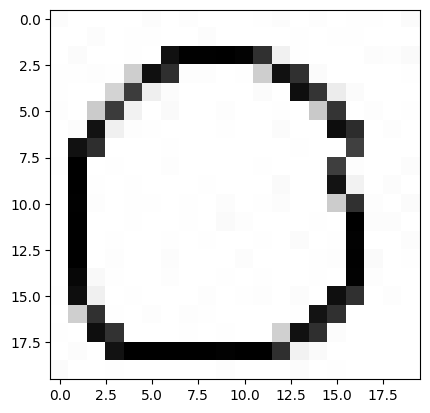

0


In [5]:
# Номер картинки
n = 11
# Отрисовка картинки
plt.imshow(x_train[n], cmap='gray')
# Вывод n-й картинки
plt.show()
# Вывод метки класса для n-го изображения
print(y_train[n])

In [6]:

x_train_n = x_train.reshape(x_train.shape[0], -1)
x_test_n = x_test.reshape(x_test.shape[0], -1)
# Проверка результата
print(f'Форма обучающих данных: {x_train.shape} -> {x_train_n.shape}')
print(f'Форма обучающих данных: {x_test.shape} -> {x_test_n.shape}')

Форма обучающих данных: (81, 20, 20, 1) -> (81, 400)
Форма обучающих данных: (21, 20, 20, 1) -> (21, 400)


In [7]:
# Нормализация входных картинок
# Преобразование x_train в тип float32 (числа с плавающей точкой) и нормализация
x_train_n = x_train_n.astype('float32') / 255.
x_test_n = x_test_n.astype('float32') / 255.

In [9]:

y_train_n = y_train
y_test_n = y_test
print(y_train_n.shape)
print(y_test_n.shape)
# Вывод примера одного выходного вектора
print(y_train_n[0])
# Вывод метки, соответствующей 100-му элементу
print(y_test_n[10])

(81,)
(21,)
0
1


In [10]:

model = Sequential()
model.add(Dense(400, input_dim=400, activation='relu'))
model.add(Dense(100, activation='relu'))
model.add(Dense(1, activation='sigmoid'))
model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])
model.fit(x_train_n, y_train_n, batch_size=8, epochs=10, verbose=1)

Epoch 1/10


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


11/11 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 0.6420 - loss: 0.6058
Epoch 2/10
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - accuracy: 0.7284 - loss: 0.4959
Epoch 3/10
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.9630 - loss: 0.2650
Epoch 4/10
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.9877 - loss: 0.1575
Epoch 5/10
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 1.0000 - loss: 0.0812
Epoch 6/10
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 1.0000 - loss: 0.0601
Epoch 7/10
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.9630 - loss: 0.1043
Epoch 8/10
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.8272 - loss: 0.3423
Epoch 9/10
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.9383 - loss: 0.1414
Epoch 10/10
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.9877 - loss: 0.0489


In [11]:
loss, accuracy = model.evaluate(x_test_n, y_test_n, verbose=0)
print("Точность:", accuracy)

Точность: 0.9523809552192688
